In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [71]:
data = {
    'order_id': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1010],
    'order_date': ['2024-01-05', '2024-01-05', '2024-01-12', '2024-02-01', 
                    '2024-02-14', '2024-02-14', '2024-03-01', '2024-03-15',
                    '2024-03-15', '2024-04-02', '2024-04-02'],
    'customer_id': [201, 202, 201, 203, 204, 205, 201, 206, 202, 207, 207],
    'category': [' Electronics', 'Grocery', 'ELECTRONICS', 'Clothing', 
                 'Grocery', 'electronics ', 'Clothing', 'Grocery', 
                 'Electronics', 'Clothing', 'Clothing'],
    'quantity': [1, 3, 2, np.nan, 5, 1, 2, 4, 1, -1, -1],
    'unit_price': [15000, 250, 8000, 1200, 300, 22000, 1500, 280, 12000, 900, 900]
}
df=pd.DataFrame(data)

In [72]:
df.head()

,order_id,order_date,customer_id,category,quantity,unit_price
0,1001,2024-01-05,201,Electronics,1.0,15000
1,1002,2024-01-05,202,Grocery,3.0,250
2,1003,2024-01-12,201,ELECTRONICS,2.0,8000
3,1004,2024-02-01,203,Clothing,NaN,1200
4,1005,2024-02-14,204,Grocery,5.0,300


In [73]:
df.tail()

,order_id,order_date,customer_id,category,quantity,unit_price
6,1007,2024-03-01,201,Clothing,2.0,1500
7,1008,2024-03-15,206,Grocery,4.0,280
8,1009,2024-03-15,202,Electronics,1.0,12000
9,1010,2024-04-02,207,Clothing,-1.0,900
10,1010,2024-04-02,207,Clothing,-1.0,900


In [74]:
df.describe()

,order_id,customer_id,quantity,unit_price
count,11.000000,11.000000,10.000000,11.000000
mean,1005.909091,203.545455,1.700000,5666.363636
std,3.176619,2.381749,1.946507,7545.571248
min,1001.000000,201.000000,-1.000000,250.000000
25%,1003.500000,201.500000,1.000000,600.000000
50%,1006.000000,203.000000,1.500000,1200.000000
75%,1008.500000,205.500000,2.750000,10000.000000
max,1010.000000,207.000000,5.000000,22000.000000


In [76]:
df.shape

(11, 6)

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   order_id     11 non-null     int64  
 1   order_date   11 non-null     str    
 2   customer_id  11 non-null     int64  
 3   category     11 non-null     str    
 4   quantity     10 non-null     float64
 5   unit_price   11 non-null     int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 660.0 bytes


In [77]:
df.isnull().sum()


order_id       0
order_date     0
customer_id    0
category       0
quantity       1
unit_price     0
dtype: int64

In [78]:
df['quantity'] = df['quantity'].replace([-1.0], np.nan)
df['quantity']

0     1.0
1     3.0
2     2.0
3     NaN
4     5.0
5     1.0
6     2.0
7     4.0
8     1.0
9     NaN
10    NaN
Name: quantity, dtype: float64

In [79]:
df['quantity'] = df['quantity'].fillna(df['quantity'].median())
df['quantity'].describe()

count    11.000000
mean      2.272727
std       1.272078
min       1.000000
25%       1.500000
50%       2.000000
75%       2.500000
max       5.000000
Name: quantity, dtype: float64

In [80]:
df.duplicated().sum()

np.int64(1)

In [81]:
df=df.drop_duplicates()

In [82]:
df['order_date']=pd.to_datetime(df['order_date'], errors='coerce', format='mixed')
df['order_month'] = df['order_date'].dt.month
df['order_weekday'] = df['order_date'].dt.day_name()

In [84]:
df['category'].unique()

<StringArray>
[' Electronics',      'Grocery',  'ELECTRONICS',     'Clothing',
 'electronics ',  'Electronics']
Length: 6, dtype: str

In [85]:
df['category'] = df['category'].str.strip().str.title()
df

,order_id,order_date,customer_id,category,quantity,unit_price,order_month,order_weekday
0,1001,2024-01-05,201,Electronics,1.0,15000,1,Friday
1,1002,2024-01-05,202,Grocery,3.0,250,1,Friday
2,1003,2024-01-12,201,Electronics,2.0,8000,1,Friday
3,1004,2024-02-01,203,Clothing,2.0,1200,2,Thursday
4,1005,2024-02-14,204,Grocery,5.0,300,2,Wednesday
5,1006,2024-02-14,205,Electronics,1.0,22000,2,Wednesday
6,1007,2024-03-01,201,Clothing,2.0,1500,3,Friday
7,1008,2024-03-15,206,Grocery,4.0,280,3,Friday
8,1009,2024-03-15,202,Electronics,1.0,12000,3,Friday
9,1010,2024-04-02,207,Clothing,2.0,900,4,Tuesday


In [86]:
df['customer_id'].unique()

array([201, 202, 203, 204, 205, 206, 207])

In [87]:
df['unit_price'].skew()

np.float64(1.1569836233258293)

In [88]:
q1=df['unit_price'].quantile(0.25)
q3=df['unit_price'].quantile(0.75)
IQR=q3-q1
lower_bound = q1-IQR*1.5
outer_bound = q3+IQR*1.5
df[(df['unit_price']<lower_bound) | (df['unit_price']>outer_bound)]

,order_id,order_date,customer_id,category,quantity,unit_price,order_month,order_weekday


<Axes: xlabel='category'>

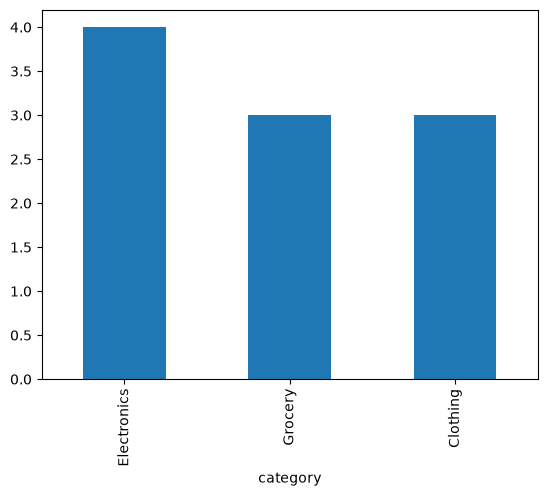

In [89]:
df['category'].value_counts().plot(kind='bar')

<Axes: xlabel='category', ylabel='count'>

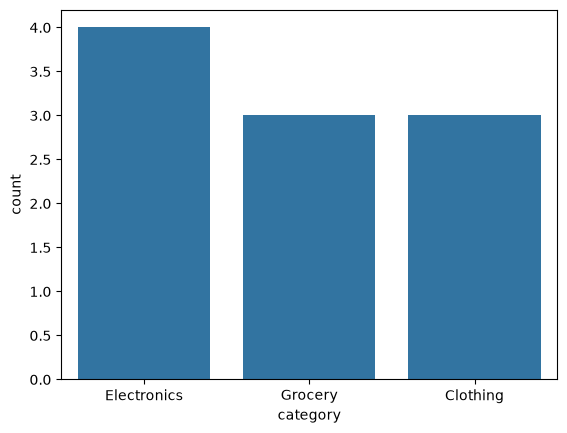

In [90]:
sns.countplot(x='category', data=df)

In [91]:
df.groupby('order_id')['unit_price'].mean()

order_id
1001    15000.0
1002      250.0
1003     8000.0
1004     1200.0
1005      300.0
1006    22000.0
1007     1500.0
1008      280.0
1009    12000.0
1010      900.0
Name: unit_price, dtype: float64

In [92]:
df.groupby(['order_date'])['unit_price'].mean()

order_date
2024-01-05     7625.0
2024-01-12     8000.0
2024-02-01     1200.0
2024-02-14    11150.0
2024-03-01     1500.0
2024-03-15     6140.0
2024-04-02      900.0
Name: unit_price, dtype: float64

In [93]:
df.groupby('category')['unit_price'].mean()

category
Clothing        1200.000000
Electronics    14250.000000
Grocery          276.666667
Name: unit_price, dtype: float64

In [94]:
df.groupby(['order_date', 'category'])['unit_price'].mean()

order_date  category   
2024-01-05  Electronics    15000.0
            Grocery          250.0
2024-01-12  Electronics     8000.0
2024-02-01  Clothing        1200.0
2024-02-14  Electronics    22000.0
            Grocery          300.0
2024-03-01  Clothing        1500.0
2024-03-15  Electronics    12000.0
            Grocery          280.0
2024-04-02  Clothing         900.0
Name: unit_price, dtype: float64

In [95]:
df['order_id'].duplicated().sum()

np.int64(0)

In [96]:
df['total_amount'] = df['unit_price']* df['quantity']

In [97]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'category', 'quantity',
       'unit_price', 'order_month', 'order_weekday', 'total_amount'],
      dtype='str')

<Axes: xlabel='unit_price', ylabel='Count'>

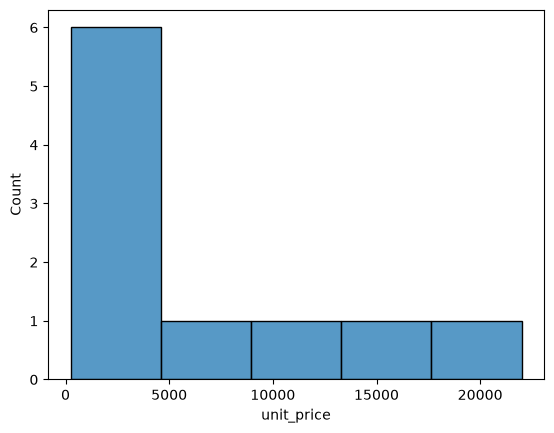

In [98]:
sns.histplot(df['unit_price'])

<Axes: xlabel='total_amount', ylabel='Count'>

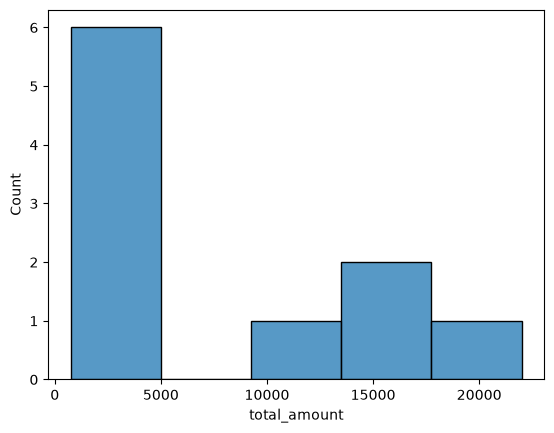

In [99]:
sns.histplot(df['total_amount'])

<Axes: xlabel='order_month', ylabel='Count'>

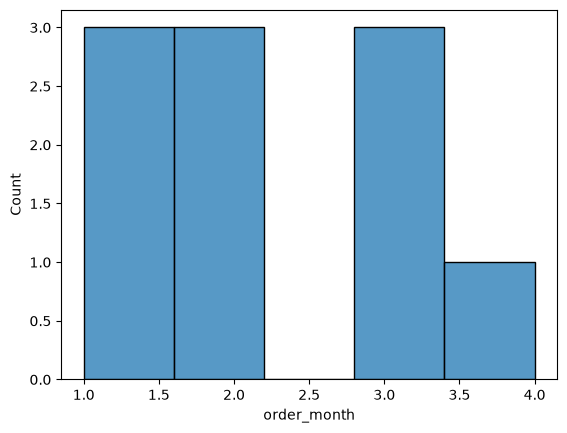

In [100]:
sns.histplot(df['order_month'])

<Axes: xlabel='quantity', ylabel='unit_price'>

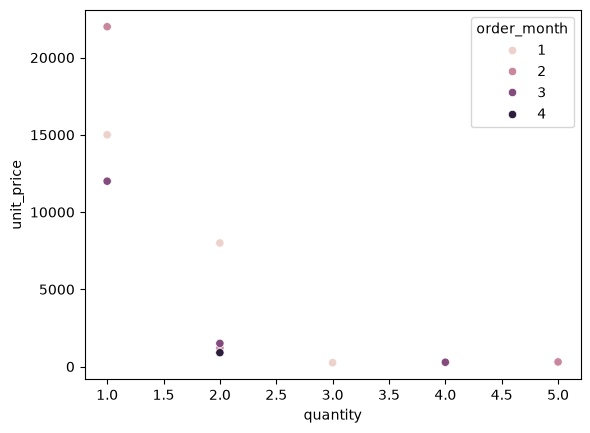

In [103]:
sns.scatterplot(x=df['quantity'], y=df['unit_price'], hue=df['order_month'])

<Axes: >

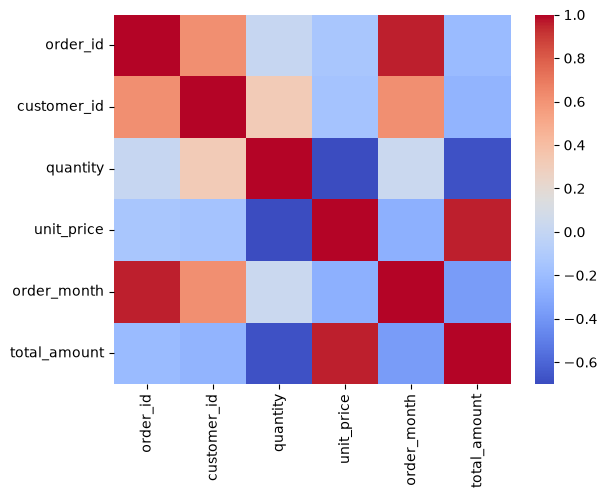

In [109]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')

In [111]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'category', 'quantity',
       'unit_price', 'order_month', 'order_weekday', 'total_amount'],
      dtype='str')

In [112]:
df.groupby('order_month')['unit_price'].mean()

order_month
1    7750.000000
2    7833.333333
3    4593.333333
4     900.000000
Name: unit_price, dtype: float64

In [ ]:
df.groupby('order_month')['total_amount'].mean()

In [119]:
grouped_month_sum = df.groupby('order_month')['total_amount'].sum()

<Axes: xlabel='order_month', ylabel='total_amount'>

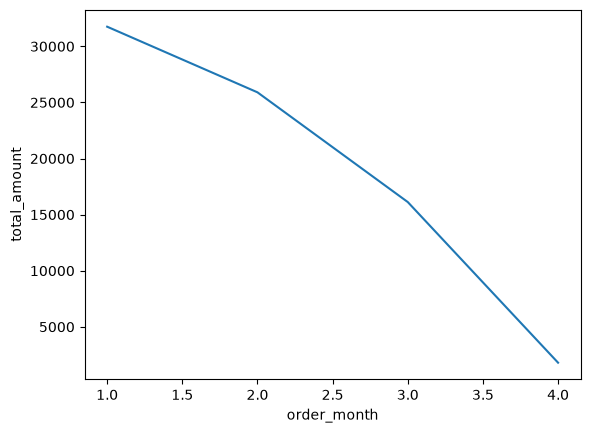

In [ ]:
sns.lineplot(grouped_month_sum)

In [124]:
df['order_weekday'].value_counts()

order_weekday
Friday       6
Wednesday    2
Thursday     1
Tuesday      1
Name: count, dtype: int64

##### there was only one missing value in quantity column but later replaced -1.0 as np.nan so 3 missing values replaced with medain of quantity column.
##### one duplicate row found with order_id=1010 it was removed.
##### converted order_date to datetime datatype.
##### looked for inconsistency and found it in category column made all values to 1st letter uppercase and rest all lowercase.
##### no outliers found but generally electronic category has unit_price higher compared to other category.
##### the data is now ready for model to be trained with.